#### import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#### Read Data and Understand it

In [2]:
ratings=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\ratings_small.csv")
movies=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\movies_metadata.csv")
links=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\links_small.csv")

C:\Users\DELL\AppData\Local\Temp\ipykernel_28156\416021315.py:2: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies=pd.read_csv(r"D:\ali\SIC\Project\Recoomend System\movies_metadata.csv\movies_metadata.csv")


In [3]:
movies.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

#### inspection and cleanning

In [4]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
movies = movies[movies['id'].str.isnumeric()]
movies['id'] = movies['id'].astype(int)
movies['budget']=movies['budget'].astype(int)
movies['popularity']=movies['popularity'].astype(float)
movies['revenue']=movies['revenue'].astype(float)

In [6]:
movies.drop(['belongs_to_collection','homepage','spoken_languages','original_title','poster_path',],inplace=True,axis=1)

In [7]:
movies.drop_duplicates(inplace=True,keep='first')

In [8]:
movies['tagline']=movies['tagline'].fillna('')
movies['overview']=movies['overview'].fillna('')

In [9]:
movies.isnull().sum()
movies.dropna(inplace=True)

In [10]:
def extract_names(field_str):
    try:
        items_list = ast.literal_eval(field_str)
        return " ".join([item['name'] for item in items_list])
    except:
        return ""

movies['production_countries'] = movies['production_countries'].apply(extract_names)
movies['production_companies'] = movies['production_companies'].apply(extract_names)
movies['genres'] = movies['genres'].apply(extract_names)

In [11]:
data_model=movies[['id','imdb_id','genres','original_language','overview','title','production_countries','production_companies','runtime','tagline']].copy()
data_model = data_model.reset_index(drop=True)

In [12]:
movies['runtime'] = movies['runtime'].replace(0, np.nan)
movies['budget'] = movies['budget'].replace(0, np.nan)
movies['revenue'] = movies['revenue'].replace(0, np.nan)
movies['runtime'] = movies['runtime'].fillna(movies['runtime'].median())
movies['budget'] = movies['budget'].fillna(movies['budget'].mean())
movies['revenue'] = movies['revenue'].fillna(movies['revenue'].mean())

In [13]:
movies=movies[movies['genres']!='']
movies=movies[movies['overview']!='']
movies=movies[movies['production_companies']!='']
movies=movies[movies['production_countries']!='']
movies=movies[movies['tagline']!='']

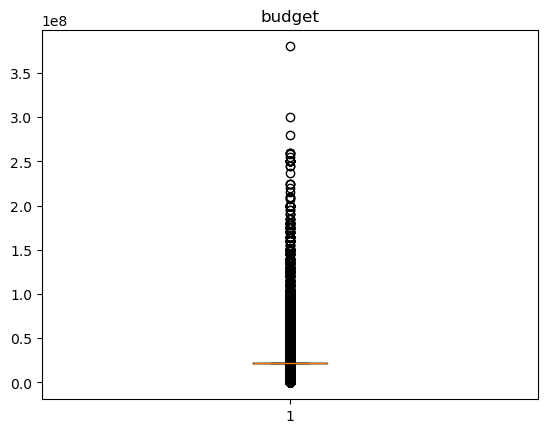

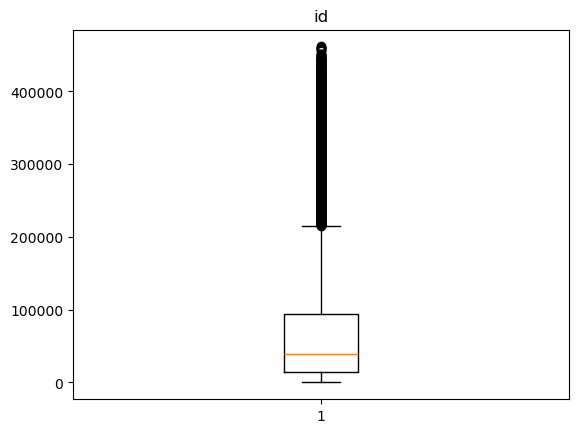

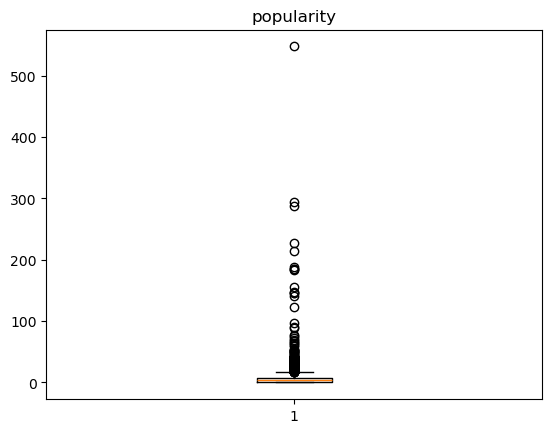

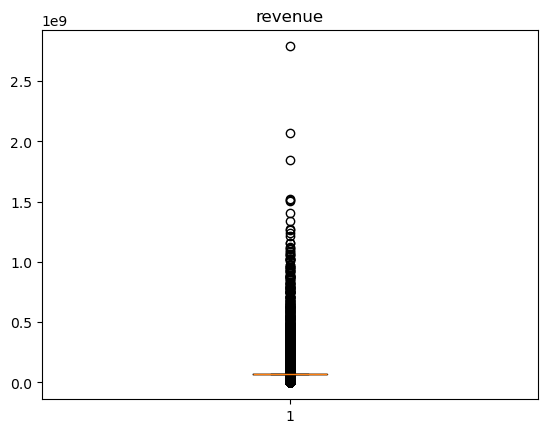

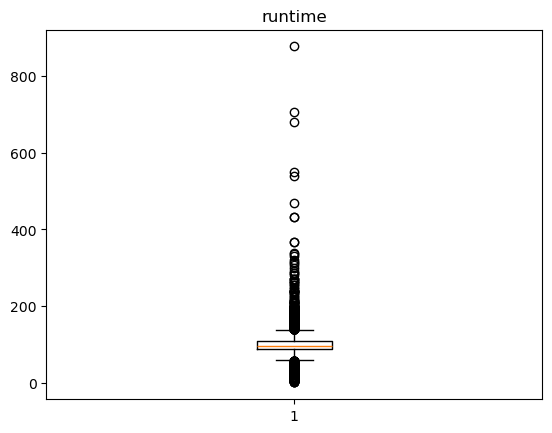

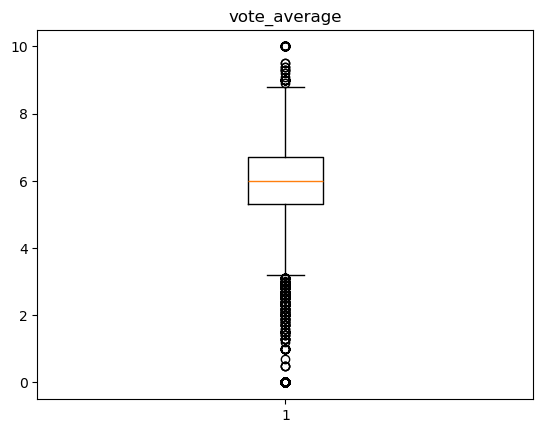

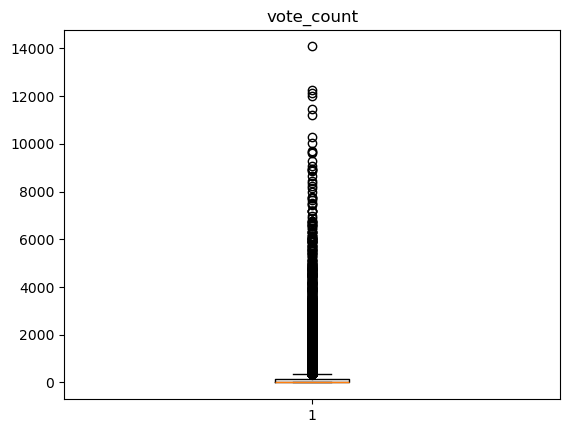

In [14]:
numeric_cols = movies.select_dtypes(include=['float64', 'int64']).columns

for i in numeric_cols:
    plt.figure()
    plt.boxplot(movies[i].dropna())
    plt.title(i)
    plt.show()

In [15]:
outlier=['popularity','vote_count','vote_average']
for i in outlier:
    q1=movies[i].quantile(.25)
    q3=movies[i].quantile(.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    movies=movies[(movies[i]>=lower)&(movies[i]<=upper)]

#### EDA and Visualization

In [16]:
movies.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,1.390700e+04,13907.000000,13907.000000,1.390700e+04,13907.000000,13907.000000,13907.000000
mean,1.929708e+07,81219.821888,3.686707,5.782609e+07,99.147839,5.906055,49.425973
std,9.340778e+06,101371.934323,3.422045,2.469482e+07,23.291884,1.043219,64.850953
min,1.000000e+00,6.000000,0.000001,1.000000e+00,1.000000,2.900000,1.000000
25%,2.164731e+07,17473.500000,0.924470,6.888892e+07,89.000000,5.200000,7.000000
50%,2.164731e+07,39973.000000,2.454107,6.888892e+07,96.000000,6.000000,21.000000
75%,2.164731e+07,89033.500000,5.765417,6.888892e+07,107.000000,6.600000,63.000000
max,1.500000e+08,461805.000000,17.714247,5.538102e+08,877.000000,8.800000,300.000000


- **Outliers & Boxplots**

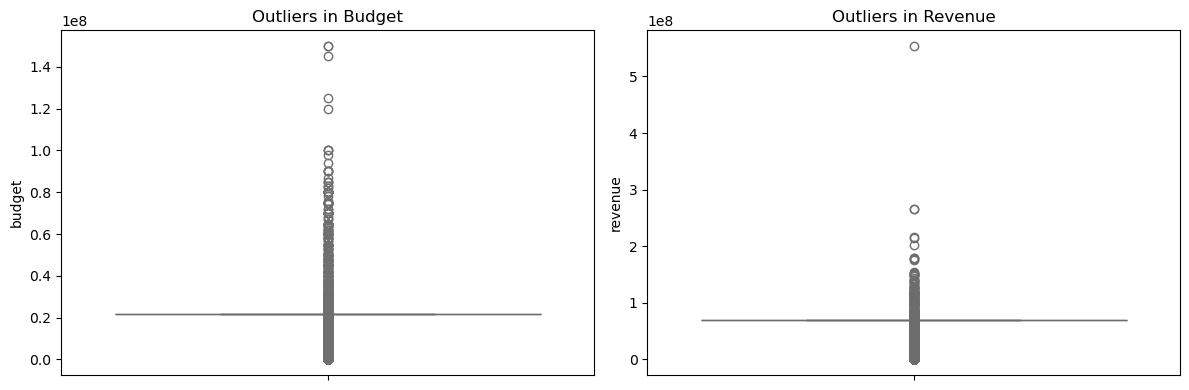

In [18]:

movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')
movies['revenue'] = pd.to_numeric(movies['revenue'], errors='coerce')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=movies['budget'], color='skyblue')
plt.title('Outliers in Budget')

plt.subplot(1, 2, 2)
sns.boxplot(y=movies['revenue'], color='salmon')
plt.title('Outliers in Revenue')

plt.tight_layout()
plt.show()

- **Heatmap**

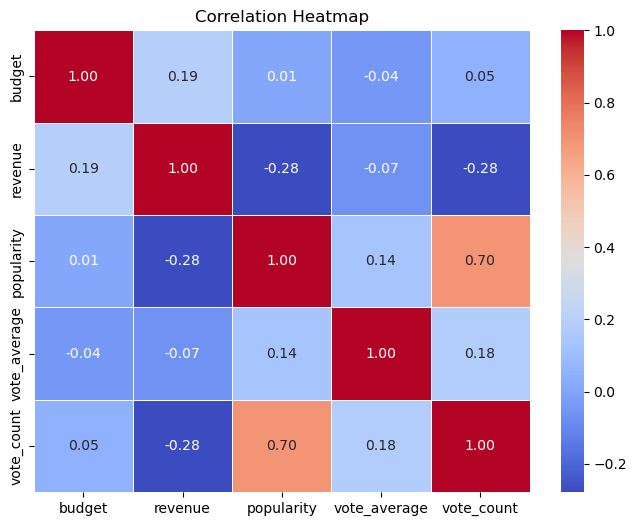

In [19]:

num_cols = ['budget', 'revenue', 'popularity', 'vote_average', 'vote_count']
num_movies = movies[num_cols].apply(pd.to_numeric, errors='coerce')
plt.figure(figsize=(8, 6))
sns.heatmap(num_movies.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

- **Missing values**

adult                   0
budget                  0
genres                  0
id                      0
imdb_id                 0
original_language       0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
status                  0
tagline                 0
title                   0
video                   0
vote_average            0
vote_count              0
dtype: int64


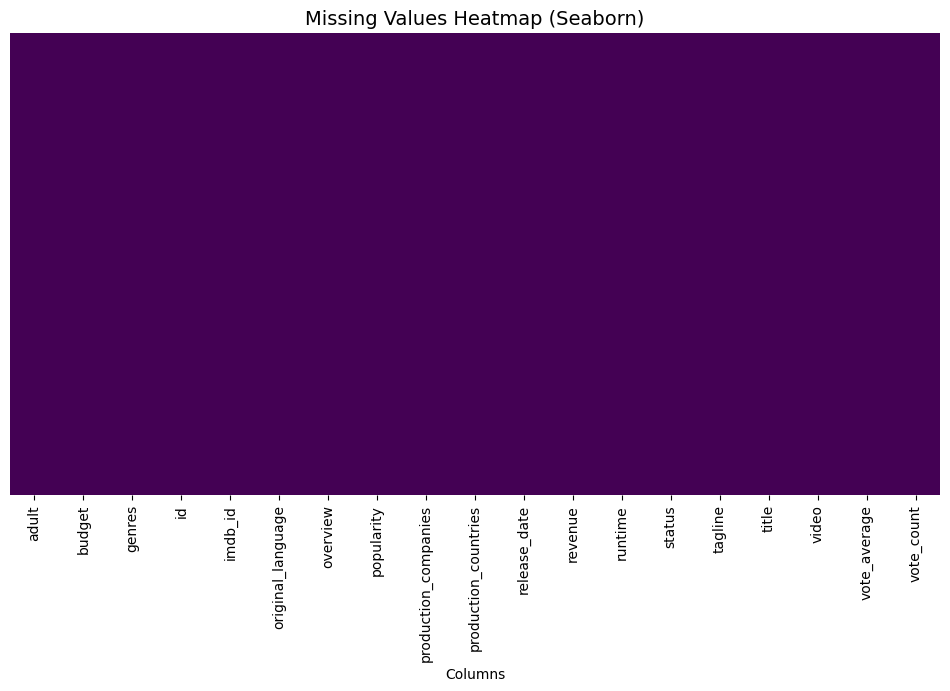

In [20]:
print(movies.isna().sum())


plt.figure(figsize=(12, 6))

sns.heatmap(movies.isna(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap (Seaborn)', fontsize=14)
plt.xlabel('Columns')
plt.show()

- **Display duration**

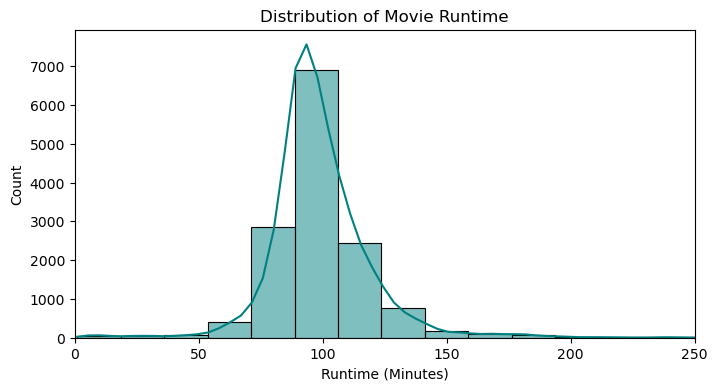

In [21]:
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce')

plt.figure(figsize=(8, 4))
sns.histplot(movies['runtime'].dropna(), bins=50, kde=True, color='teal')
plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Count')
plt.xlim(0, 250)
plt.show()



- **Rating & Vote Distribution**

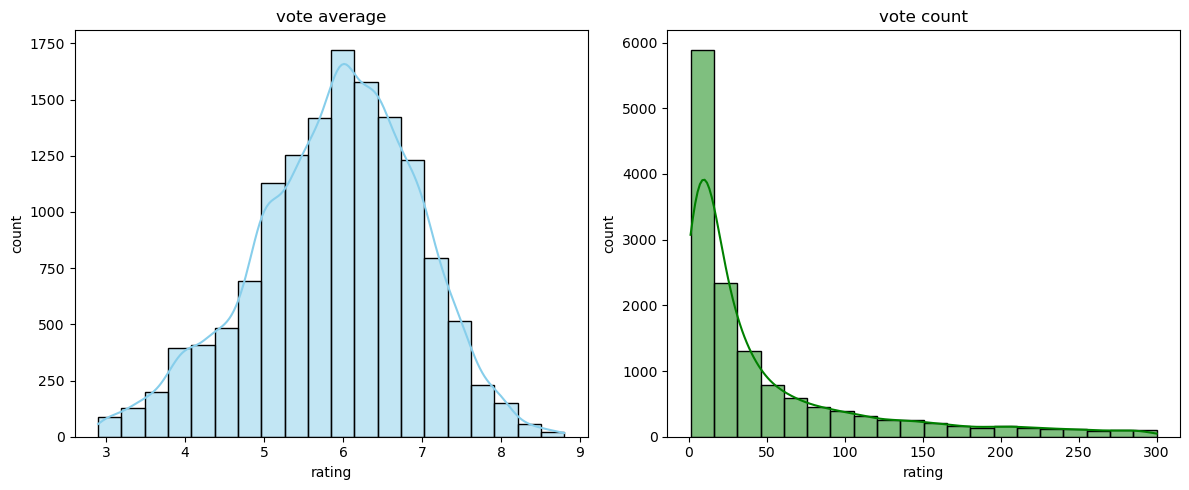

In [23]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(movies['vote_average'], bins=20, kde=True, color='skyblue')
plt.title('vote average')
plt.xlabel('rating')
plt.ylabel('count')

plt.subplot(1, 2, 2)
sns.histplot(movies['vote_count'], bins=20, kde=True, color='green')
plt.title('vote count')
plt.xlabel('rating')
plt.ylabel('count')

plt.tight_layout()
plt.show()



- **films types**

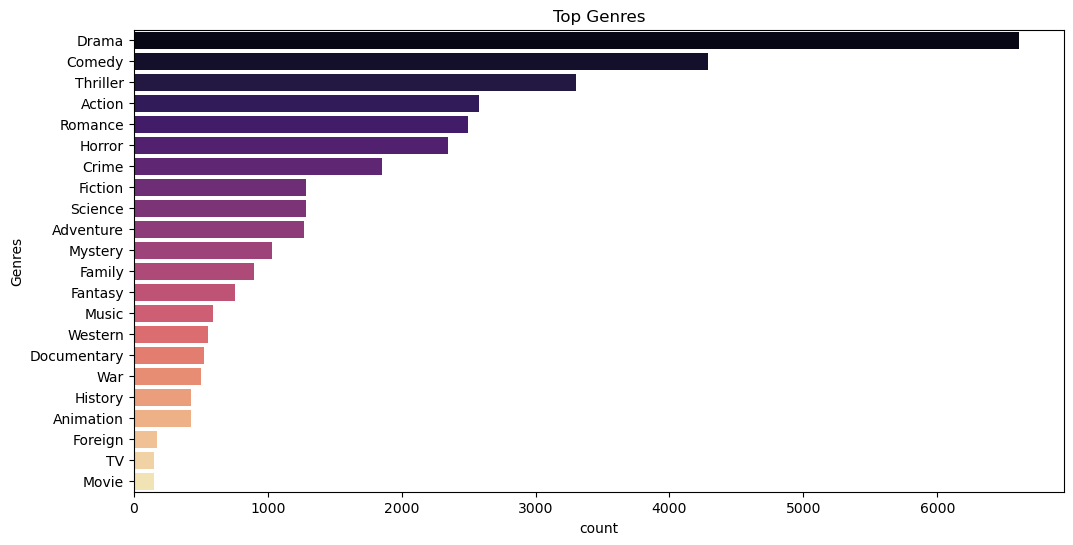

In [24]:
from collections import Counter


all_genres = " ".join(movies['genres'].dropna()).split()

genre_counts = Counter(all_genres)


genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count']).sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))

sns.barplot(data=genre_df, x='Count', y='Genre', hue='Genre', legend=False, palette='magma')
plt.title('Top Genres')
plt.xlabel('count')
plt.ylabel('Genres')
plt.show()

- **top 10 films**

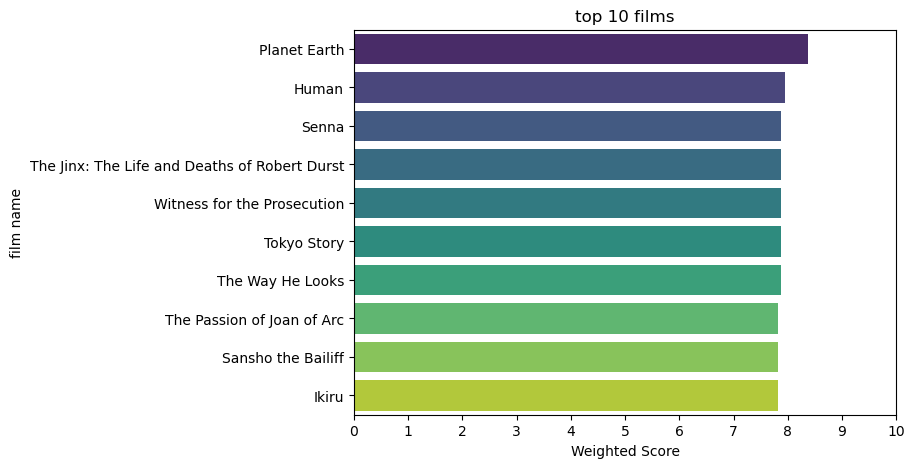

In [25]:

C = movies['vote_average'].mean() # average rating films (c)


m = movies['vote_count'].quantile(0.60) # movies with a rating 0.60 or more

q_movies = movies.copy().loc[movies['vote_count'] >= m] #Filter movies under review


def weighted_rating(x, m=m, C=C): # calculate the weighted_rating of film
    v = x['vote_count']
    R = x['vote_average']
    return (v / (v + m) * R) + (m / (m + v) * C)


q_movies['score'] = q_movies.apply(weighted_rating, axis=1)  #Storing outputs weighted_rating


top_10 = q_movies.sort_values('score', ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(data=top_10, x='score', y='title', hue='title', legend=False, palette='viridis')
plt.title('top 10 films')
plt.xlabel('Weighted Score')
plt.ylabel('film name')

plt.xticks(range(0, 11))
plt.show()

- **top 10 language**

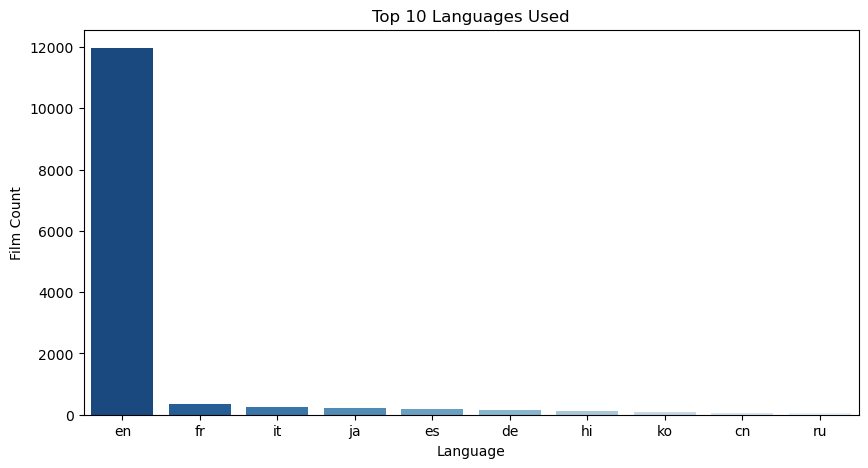

In [26]:
top_languages = movies['original_language'].value_counts().head(10) # top 10 language used

plt.figure(figsize=(10, 5))

sns.barplot(x=top_languages.index, y=top_languages.values, hue=top_languages.index, palette='Blues_r', legend=False)

plt.title('Top 10 Languages Used')
plt.xlabel('Language')
plt.ylabel('Film Count')
plt.show()

- **User Opinions**

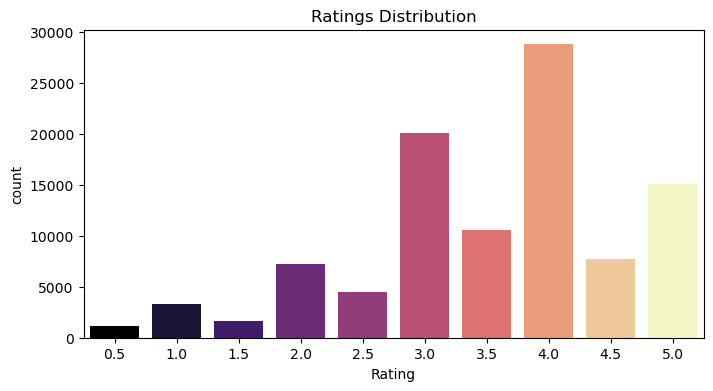

In [27]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ratings, x='rating', hue='rating', legend=False, palette='magma')
plt.title('Ratings Distribution')
plt.xlabel('Rating')
plt.ylabel('count')
plt.show()





- **Top Production Companies**

C:\Users\DELL\AppData\Local\Temp\ipykernel_28156\1756910175.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comp_df, x='Count', y='Company', palette='magma')


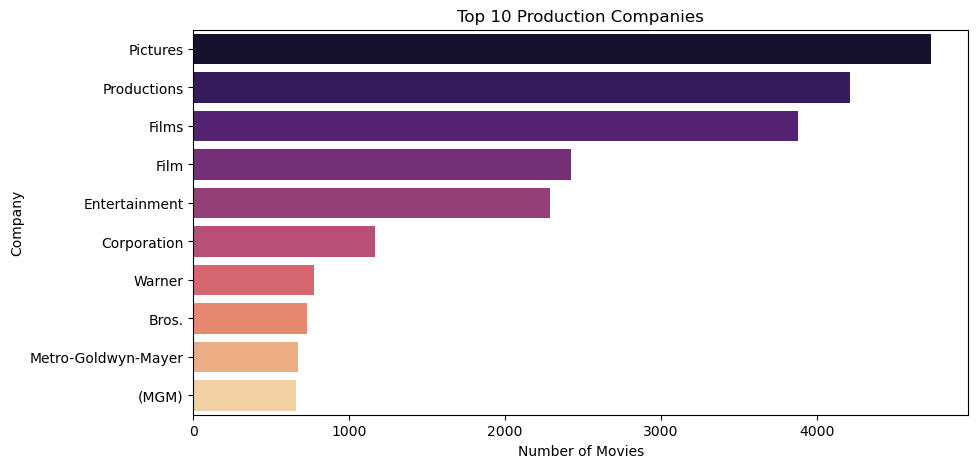

In [28]:
all_companies = [comp for sublist in movies['production_companies'].str.split() for comp in sublist]
company_counts = Counter(all_companies).most_common(10)

comp_df = pd.DataFrame(company_counts, columns=['Company', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=comp_df, x='Count', y='Company', palette='magma')
plt.title('Top 10 Production Companies')
plt.xlabel('Number of Movies')
plt.show()

-  **top revenue movies**

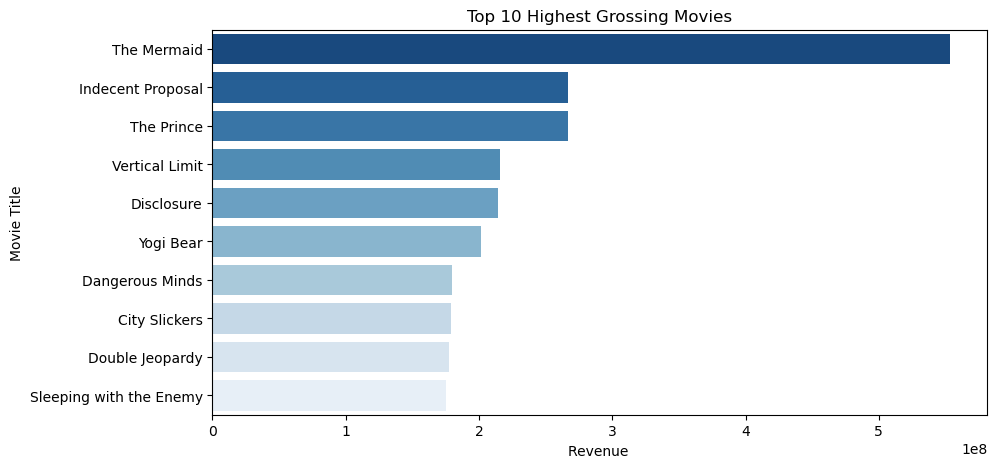

In [29]:

top_revenue_movies = movies.nlargest(10, 'revenue')[['title', 'revenue']]

plt.figure(figsize=(10, 5))


sns.barplot(
    data=top_revenue_movies,
    x='revenue',
    y='title',
    hue='title',
    palette='Blues_r',
    legend=False
)

plt.title('Top 10 Highest Grossing Movies')
plt.xlabel('Revenue ')
plt.ylabel('Movie Title')
plt.show()

- **top_10_budget**

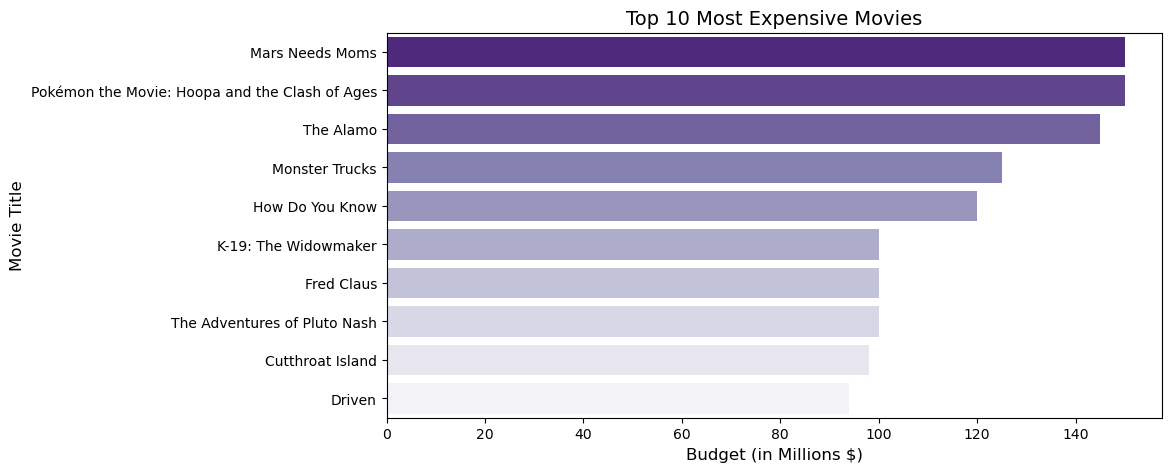

In [30]:
top_10_budget = movies.sort_values(by='budget', ascending=False).head(10).copy()


top_10_budget['budget_millions'] = top_10_budget['budget'] / 1e6 #Convert to millions


plt.figure(figsize=(10, 5))
sns.barplot(data=top_10_budget, x='budget_millions', y='title', hue='title', palette='Purples_r', legend=False)

plt.title('Top 10 Most Expensive Movies', fontsize=14)
plt.xlabel('Budget (in Millions $)', fontsize=12)
plt.ylabel('Movie Title', fontsize=12)
plt.show()